# Make figures for changepoint detection paper - R1

In [69]:
import xarray as xr
import numpy as np
import pandas as pd
import os
from glob import glob
from helpful_utilities import xutils
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import string
import matplotlib.gridspec as gridspec
from cartopy.util import add_cyclic_point


import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
%matplotlib inline

In [70]:
from helpful_utilities.plotting import easy_map
from helpful_utilities.ncutils import lon_to_180, lon_to_360

In [71]:
procdir = '/home/data/projects/homogenization/proc'
figdir = '/home/kmckinnon/homogenization/figs/R1'
fontsize = 12
labelsize = 10

letters = list(string.ascii_lowercase)
years = 1980, 2024

In [72]:
f_lsmask_1x1 = '/home/data/ERA5/fx/era5_lsmask_1x1.nc'
da_lsmask_1x1 = xr.open_dataarray(f_lsmask_1x1).squeeze()
landcut = 0.5
is_land = (da_lsmask_1x1 > landcut) & (da_lsmask_1x1.lat > -60) & (da_lsmask_1x1.lat < 80)

In [73]:
# get aridity index based on TerraClim climatologies
tc_ppt = lon_to_360(xr.open_dataarray('/home/data/Terraclim/PPT_Terraclim_1980_2020_native.nc').sortby('lat'))
tc_pet = lon_to_360(xr.open_dataarray('/home/data/Terraclim/PET_Terraclim_1980_2020_native.nc').sortby('lat'))

arid_idx_1x1 = (tc_ppt / tc_pet).interp({'lat': da_lsmask_1x1.lat, 'lon': da_lsmask_1x1.lon})

/home/kmckinnon/.conda/envs/homogenization/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in subtract
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/kmckinnon/.conda/envs/homogenization/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in add
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [74]:
is_arid_semi = ((arid_idx_1x1 > 0.05) & (arid_idx_1x1 < 0.5)).where(da_lsmask_1x1.squeeze() > landcut)


## Synthetic tests: load data

In [52]:
synth_cp_std = 0.5
seed = 0
namestr = '_with_skew' #_ncp-1'
model_str = ''  # '_models-trendar1'

# Contains the trend, AR(1), and seasonally-varying variance for each gridbox
ds_residual_metrics = xr.open_dataset('%s/residual_metrics_with_skew.nc' % procdir)

# landmask
mask = ~np.isnan(ds_residual_metrics['ar1'])

# Truth
# actual changepoint magnitude
da_cp_synth = xr.open_dataarray('%s/synth_cps_cpmag%s_sigma-%0.1f_seed-%i%s.nc' % (procdir, namestr,
                                                                                 synth_cp_std, seed, 
                                                                                   model_str))

# actual changepoint time index -- cannot be in first and last 5 years (60 time points)
da_cp_time_synth = xr.open_dataarray('%s/synth_cps_time%s_sigma-%0.1f_seed-%i%s.nc' % (procdir, namestr,
                                                                                   synth_cp_std, seed,
                                                                                      model_str))



# Output from using PELT
# detected changepoint magnitude
da_delta_at_cp_synth = xr.open_dataarray('%s/da_delta_at_cp_synth%s_sigma-%0.1f_seed-%i%s.nc' % (procdir, 
                                                                                               namestr,
                                                                                             synth_cp_std,
                                                                                             seed,
                                                                                                model_str))
# other info e.g. time of changepoint
ds_cp_info_synth = xr.open_dataset('%s/ds_cp_info_synth%s_sigma-%0.1f_seed-%i%s.nc' % (procdir, namestr,
                                                                                   synth_cp_std, seed, 
                                                                                       model_str))

print('There are %i gridboxes analyzed' % (np.sum(mask==1)))

There are 15080 gridboxes analyzed


## Plot: hit / miss / false alarm histogram as a function of CP magnitude + role of different characteristics

In [53]:
# Time of actual CP
idx_actual = da_cp_time_synth
# Time CP was detected - first changepoint only
idx_detected = ds_cp_info_synth['cp_index'].sel(cp=0)

is_land_vec = is_land.values.flatten()

# Hit is defined as a changepoint found within a year on either side
hit = (idx_detected >= (idx_actual - 12)) & (idx_detected <= (idx_actual + 12))
# Miss: no changepoint found
miss = (ds_cp_info_synth['cp_count']==1)
# False alarm: changepoint found, but not at the right time
false_alarm = (ds_cp_info_synth['cp_count'] > 1) & ~hit

In [54]:
print('False alarm rate: %0.2f' % (false_alarm.where(mask).sum() / (mask==1).sum()))

False alarm rate: 0.02


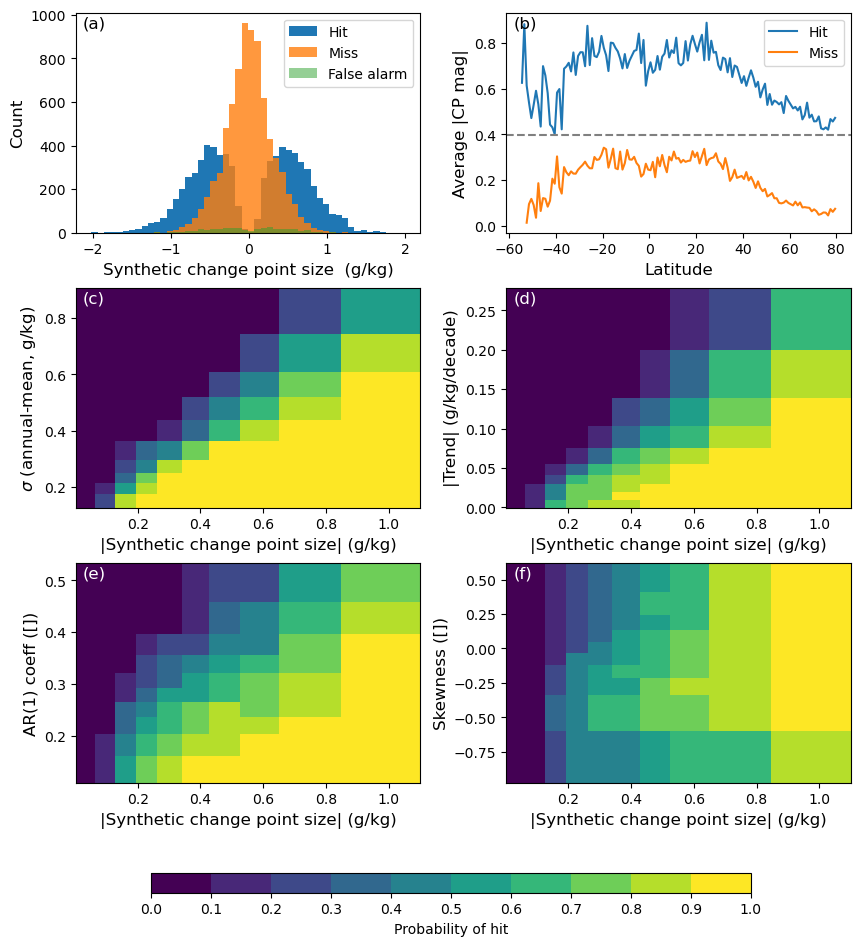

In [55]:
fig, axes = plt.subplots(figsize=(10, 10), ncols=2, nrows=3, gridspec_kw={'wspace': 0.25, 'hspace': 0.25})

# For probability plots
bounds = np.arange(0, 1.01, 0.1)
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(bounds, cmap.N)

bin_qsize = 10
bins_q = np.arange(0, 100 + bin_qsize, bin_qsize) / 100
bin_middle = (bins_q[1:] + bins_q[:-1]) / 2
nbins = len(bins_q) - 1

var1 = np.abs(da_cp_synth.where(mask))
name1 = '|Synthetic change point size| (g/kg)'

for ct, ax in enumerate(axes.flatten()):
    if ct == 0: # histograms
        nhit, bins, _ = ax.hist(da_cp_synth.where(hit).values.flatten(), bins=50, label='Hit')
        nmiss, _, _ = ax.hist(da_cp_synth.where(miss).values.flatten(), bins=bins, label='Miss', alpha=0.8)
        nFA, _, _ = ax.hist(da_cp_synth.where(false_alarm).values.flatten(), bins=bins, label='False alarm', 
                             alpha=0.5)
        ax.legend()
        ax.set_xlabel('Synthetic change point size  (g/kg)', fontsize=fontsize)
        ax.set_ylabel('Count', fontsize=12)
        ax.text(0.02, 0.93, '(a)', fontsize=fontsize, transform=ax.transAxes, zorder=10)
        
    elif ct == 1:  # latitude behavior
        np.abs(da_cp_synth.where(hit)).mean('lon').plot(ax=ax, label='Hit',)
        np.abs(da_cp_synth.where(miss)).mean('lon').plot(ax=ax, label='Miss')
        expected = synth_cp_std * np.sqrt(2 / np.pi)
        ax.axhline(expected, ls='--', color='gray')
        ax.legend(loc='upper right')
        ax.set_title('')
        ax.set_xlabel('Latitude', fontsize=fontsize)
        ax.set_ylabel('Average |CP mag|', fontsize=fontsize)
        ax.text(0.02, 0.93, '(b)', fontsize=fontsize, transform=ax.transAxes, zorder=10)
    else:

        if ct == 2:
            var2 = (np.sqrt((ds_residual_metrics['clim_std'] ** 2).mean('month')))
            name2 = r'$\sigma$ (annual-mean, g/kg)'
        elif ct == 3:
            var2 = 10 * np.abs(ds_residual_metrics['trend'])
            name2 = '|Trend| (g/kg/decade)'
        elif ct == 4:
            var2 = ds_residual_metrics['ar1']
            name2 = 'AR(1) coeff ([])'
        elif ct == 5:
            var2 = ds_residual_metrics['skew']
            name2 = 'Skewness ([])'
            
        var2 = var2.where(mask)

        p_hit = np.empty((nbins, nbins))
        for i in range(nbins):
            for j in range(nbins):
                idx1 = (var1 >= var1.quantile(bins_q[i])) & (var1 < var1.quantile(bins_q[i + 1]))
                idx2 = (var2 >= var2.quantile(bins_q[j])) & (var2 < var2.quantile(bins_q[j + 1]))

                in_bin = idx1 & idx2
                p_hit[j, i] = hit.where(in_bin).sum() / ((hit + miss + false_alarm).where(in_bin).sum())

        xlabel = var1.quantile(bin_middle)
        ylabel = var2.quantile(bin_middle)
        # fig, ax = plt.subplots(figsize=(8, 5))

        im = ax.pcolormesh(
            xlabel, ylabel, p_hit,
            cmap=cmap, norm=norm,
            shading='auto'
        )

        ax.set_xlabel(name1, fontsize=fontsize)
        ax.set_ylabel(name2, fontsize=fontsize)
        
        ax.text(0.02, 0.93, '(%s)' % letters[ct], color='white', 
                fontsize=fontsize, transform=ax.transAxes)

# after creating your figure and subplots
fig = plt.gcf()

# [left, bottom, width, height] in figure coordinates (0–1)
cax = fig.add_axes([0.2, 0, 0.6, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Probability of hit')
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{b:.1f}' for b in bounds])
plt.savefig('%s/fig01.png' % figdir, dpi=200, bbox_inches='tight')


In [65]:
nhit, bins, _ = ax.hist(np.abs(da_cp_synth.where(hit).values.flatten()), bins=40, label='Hit')
nmiss, _, _ = ax.hist(np.abs(da_cp_synth.where(miss).values.flatten()), bins=bins, label='Miss', alpha=0.8)
nFA, _, _ = ax.hist(np.abs(da_cp_synth.where(false_alarm).values.flatten()), bins=bins, label='False alarm', 
                     alpha=0.5)

In [68]:
phit = nhit / (nhit + nmiss + nFA)
bin_mid = 1/2 * (bins[1:] + bins[:-1])

print('50 percent chance of hit: %0.2f' % bin_mid[3:-3][np.argmin(np.abs(phit[3:-3] - 0.5))])
print('75 percent chance of hit: %0.2f' % bin_mid[3:-3][np.argmin(np.abs(phit[3:-3] - 0.75))])

50 percent chance of hit: 0.32
75 percent chance of hit: 0.57


/tmp/ipykernel_921864/1070460666.py:1: RuntimeWarning: invalid value encountered in divide
  phit = nhit / (nhit + nmiss + nFA)


## ERA5 and HadISDH changepoint results map and years

In [12]:
data_names = ['ERA5', 'HadISDH']
years = 1980, 2024

In [13]:
# Get mask from HadISDH analysis
f = '%s/ds_cp_info_%s_%04i-%04i.nc' % (procdir, 'HadISDH', years[0], years[1])
ds_cp = xr.open_dataset(f)
# In mask, 1 = missing
had_mask = ds_cp.sel(cp=0)['model_code'] == -1 

had_lsmask = xr.open_dataarray('/home/data/ERA5/fx/era5_lsmask_5x5_conservative.nc')
had_lsmask = had_lsmask.squeeze()

In [14]:
# 1 is missing over land only for stippling
had_mask = had_mask & (had_lsmask > landcut).astype(bool).sel(lat=had_mask.lat)

da_delta_at_cp_withAR_ERA5_Q2m_minus_CESM2_QREFHT.nc   
ds_cp_info_ERA5_Q2m_minus_CESM2_QREFHT.nc   
fitted_da_withAR_ERA5_Q2m_minus_CESM2_QREFHT.nc

min-max range: -1.15-1.06
min-max range: -2.18-0.64


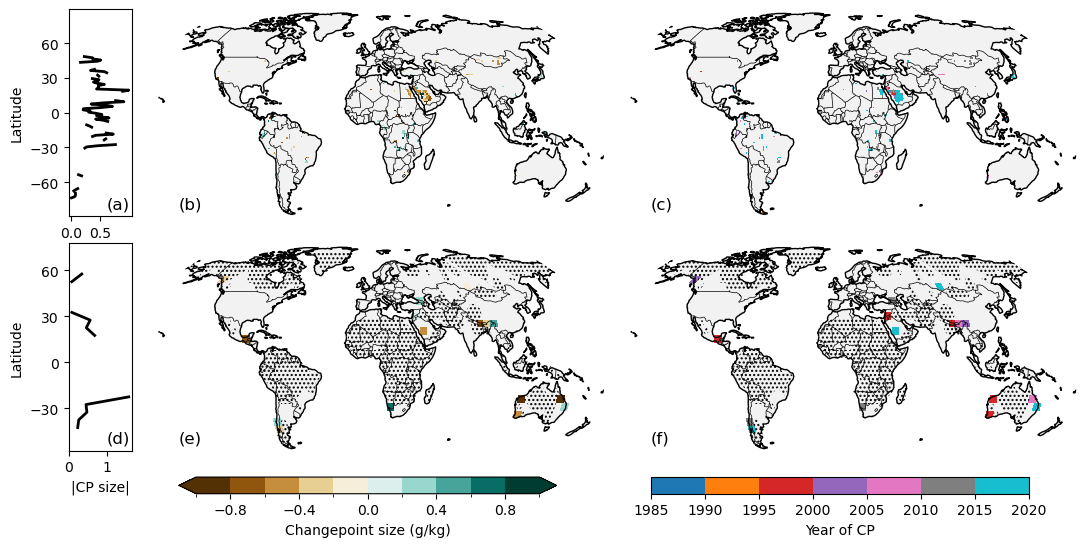

In [15]:
n_data = len(data_names)
nrows = n_data + 1
ncols = 3

proj = ccrs.Robinson(central_longitude=0)
cp_to_plot = 1  # plot first changepoint (0) or second (1)

fig = plt.figure(figsize=(13, 6.3))

gs = gridspec.GridSpec(
    nrows=nrows,
    ncols=ncols,
    width_ratios=[0.8, 6, 6],
    height_ratios=[1] * n_data + [0.08],
    wspace=0,
    hspace=0.18
)

letter_ct = 0

cbar_info = {
    0: {'im': None, 'label': None, 'extend': None},
    1: {'im': None, 'label': None, 'extend': None},
}

profile_axes = []
first_map_axes = []

for ct, data_name in enumerate(data_names):

    # Plot profile and map
    ax_prof = fig.add_subplot(gs[ct, 0])
    profile_axes.append(ax_prof)
    
    if data_name == 'HadISDH':
        f = '%s/da_delta_at_cp_withAR_%s_%04i-%04i.nc' % (
            procdir, data_name, years[0], years[1]
        )
    else:
        f = '%s/changepoints_1x1/da_delta_at_cp_withAR_ERA5_Q2m_minus_CESM2_QREFHT.nc' % procdir
        
    with xr.open_dataarray(f) as da_mag:
        if data_name == 'HadISDH': 
            smooth_prof = np.abs(da_mag).sel(cp=cp_to_plot).mean('lon').load()
        else:
            smooth_prof = (
                np.abs(da_mag.where(da_lsmask_1x1 > landcut))
                .sel(cp=cp_to_plot)
                .mean('lon')
                .load()
            )

        lat_min = da_mag['lat'].min().values
        lat_max = da_mag['lat'].max().values
        da_mag = da_mag.sel(cp=cp_to_plot).load()
        
    if data_name == 'HadISDH':
        cp_info_file = '%s/ds_cp_info_%s_%i-%i.nc' % (
            procdir, data_name, years[0], years[1]
        )
    else:
        cp_info_file = '%s/changepoints_1x1/ds_cp_info_ERA5_Q2m_minus_CESM2_QREFHT.nc' % procdir

    with xr.open_dataset(cp_info_file) as ds_cp_info:
        da_time = ds_cp_info['cp_time'].sel(cp=cp_to_plot).dt.year
        has_cp = ds_cp_info['cp_count'] >= 2
        has_cp = has_cp.load()
        da_time = da_time.where(has_cp & (da_time < years[-1])).load()
        
    if data_name != 'HadISDH':
        da_mag = da_mag.where(da_lsmask_1x1 > landcut)
        da_time = da_time.where(da_lsmask_1x1 > landcut)

    smooth_prof.plot(ax=ax_prof, y='lat', color='k', lw=2)

    if ct == n_data - 1: 
        ax_prof.set_xlabel('|CP size|')
    else:
        ax_prof.set_xlabel('')

    if ct == 0:
        ax_prof.set_xticks((0, 0.5))
    else:
        ax_prof.set_xticks((0, 1))

    ax_prof.set_yticks(np.arange(-60, 80, 30))
    ax_prof.set_ylabel('Latitude')
    ax_prof.set_title('')
    ax_prof.set_ylim(lat_min, lat_max)

    ax_prof.text(
        0.6, 0.04, '(%s)' % letters[letter_ct],
        fontsize=fontsize,
        transform=ax_prof.transAxes
    )
    letter_ct += 1

    for map_ct in range(2):

        ax_map = fig.add_subplot(gs[ct, 1 + map_ct], projection=proj)
        ax_map.set_aspect('equal')

        if map_ct == 0:
            first_map_axes.append(ax_map)

            # Plot CP magnitude
            cmap = plt.cm.BrBG
            levels = np.arange(-1, 1.1, 0.2)
            label = 'Changepoint size (g/kg)'
            extend = 'both'
            norm = BoundaryNorm(levels, ncolors=256)    
            to_plot = da_mag

            print(
                'min-max range: %0.2f-%0.2f'
                % (to_plot.min(), to_plot.max())
            )

        else:
            # Plot CP year
            cmap = plt.cm.tab10
            ncolors = 10
            levels = np.arange(1985, 2021, 5)
            label = 'Year of CP'
            extend = 'neither'
            norm = BoundaryNorm(levels, ncolors=ncolors)
            to_plot = da_time

        lon = to_plot['lon'].values
        lat = to_plot['lat'].values
        dat = to_plot.values

        dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

        im = ax_map.pcolormesh(
            lon_cyc,
            lat,
            dat_cyc,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            shading='auto'
        )

        if cbar_info[map_ct]['im'] is None:
            cbar_info[map_ct]['im'] = im
            cbar_info[map_ct]['label'] = label
            cbar_info[map_ct]['extend'] = extend

        ax_map.add_feature(cfeature.LAND, color='0.95', zorder=0)
        ax_map.add_feature(cfeature.COASTLINE, zorder=100)
        ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=100)

        ax_map.set_global()
        ax_map.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
        ax_map.axis('off')
        ax_map.set_title('')

        # HadISDH hatch overlay, rendered in same cyclic/pcolormesh-aligned style
        if data_name == 'HadISDH':
            had_lon = had_mask['lon'].values
            had_lat = had_mask['lat'].values
            had_dat = had_mask.values
            had_cyc, had_lon_cyc = add_cyclic_point(had_dat, coord=had_lon)

            ax_map.contourf(
                had_lon_cyc,
                had_lat,
                had_cyc,
                levels=[-0.5, 0.5, 1.5],
                hatches=[None, '....'],
                colors='none',
                transform=ccrs.PlateCarree(),
                zorder=101
            )

        ax_map.text(
            0.10, 0.04, '(%s)' % letters[letter_ct],
            fontsize=fontsize,
            transform=ax_map.transAxes
        )
        letter_ct += 1


# Force profile axes to match the final Cartopy map heights
fig.canvas.draw()

for ax_prof, ax_map in zip(profile_axes, first_map_axes):
    pos_map = ax_map.get_position()
    pos_prof = ax_prof.get_position()
    ax_prof.set_position([
        pos_prof.x0,
        pos_map.y0,
        pos_prof.width,
        pos_map.height
    ])


# Empty lower-left cell
ax_empty = fig.add_subplot(gs[-1, 0])
ax_empty.axis('off')


# Colorbars in the bottom GridSpec row
# Colorbars in the bottom GridSpec row, spanning 80% of each map-column axis
for map_ct in range(2):

    cax = fig.add_subplot(gs[-1, 1 + map_ct])

    # shrink colorbar axis to 80% width, centered in its GridSpec cell
    fig.canvas.draw()
    pos = cax.get_position()

    frac = 0.8
    new_width = frac * pos.width
    new_x0 = pos.x0 + 0.5 * (pos.width - new_width)

    cax.set_position([
        new_x0,
        pos.y0,
        new_width,
        pos.height
    ])

    cbar = fig.colorbar(
        cbar_info[map_ct]['im'],
        cax=cax,
        orientation='horizontal',
        extend=cbar_info[map_ct]['extend']
    )

    cbar.set_label(cbar_info[map_ct]['label'])


if cp_to_plot == 0:
    plt.savefig('%s/fig02.png' % figdir, dpi=200, bbox_inches='tight')
else:
    plt.savefig('%s/figS07.png' % figdir, dpi=200, bbox_inches='tight')

In [16]:
# print out stats for ERA5 -- land are with changepoint
f = '%s/changepoints_1x1/ds_cp_info_ERA5_Q2m_minus_CESM2_QREFHT.nc' % procdir
with xr.open_dataset(f) as ds_cp:
    has_cp = ds_cp['cp_count'].where(is_land)
area_with_cp = xutils.area_weighted_average((has_cp > 1).where(has_cp > 0))
f = '%s/changepoints_1x1/da_delta_at_cp_withAR_ERA5_Q2m_minus_CESM2_QREFHT.nc' % procdir
with xr.open_dataarray(f) as da_mag:
    median_cp = np.abs(da_mag.where(is_land)).median()

print('ERA5 stats')
print('Fraction of land area with CP: %0.2f' % area_with_cp)
print('Median CP magnitude: %0.2f' % median_cp)


ERA5 stats
Fraction of land area with CP: 0.31
Median CP magnitude: 0.40


# Figure S1: changepoints in ERA5 winds

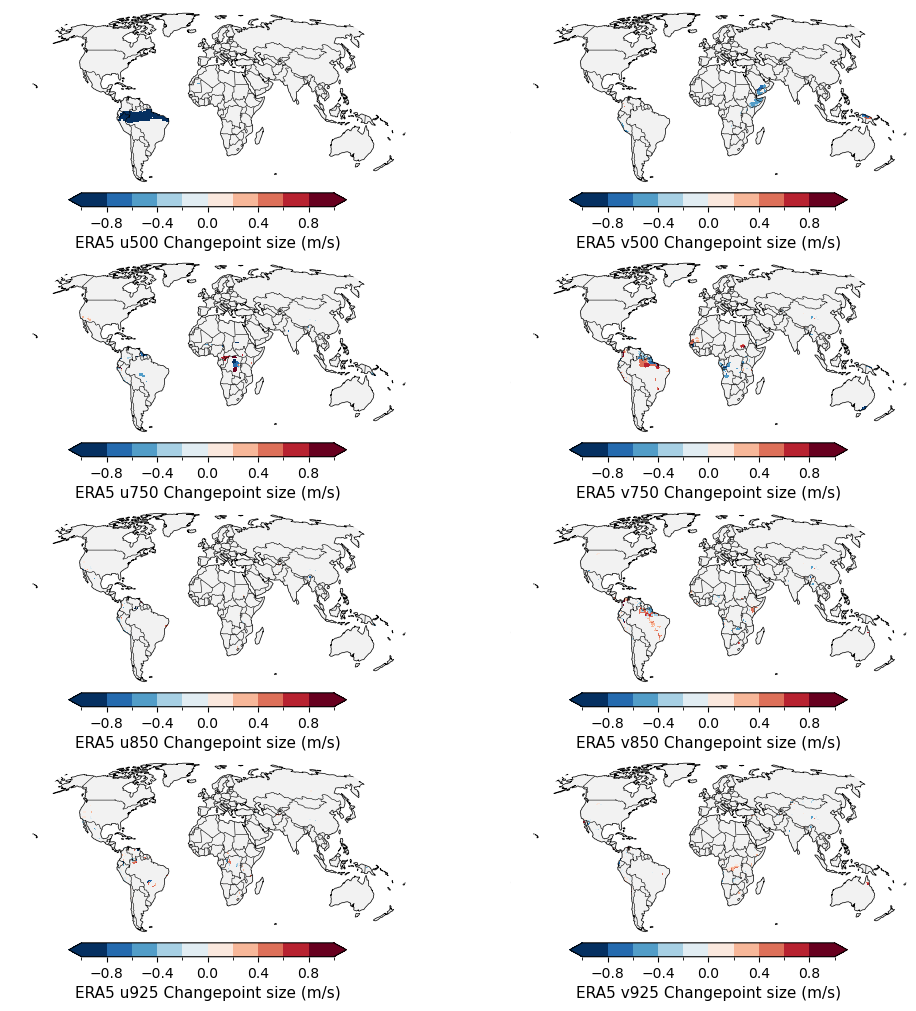

In [19]:
cp_to_plot = 0
fontsize = 11

procdir = '/home/data/projects/homogenization/proc'
cpdir = f'{procdir}/changepoints_1x1'   # change if needed

levels_use = [500, 750, 850, 925]
vars_use = ['u', 'v']

proj = ccrs.Robinson(central_longitude=0)

# Variable-specific plotting ranges
plot_settings = {
    'u500': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
    'u750': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
    'u850': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
    'u925': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
    'v500': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
    'v750': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
    'v850': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
    'v925': {'levels': np.arange(-1, 1.1, 0.2), 'label': 'Changepoint size (m/s)'},
}

cmap = plt.cm.RdBu_r

fig, axes = plt.subplots(
    len(levels_use),
    len(vars_use),
    figsize=(10, 10),
    subplot_kw={'projection': proj},
    constrained_layout=True,
)

for i, lev in enumerate(levels_use):
    for j, var in enumerate(vars_use):

        ax = axes[i, j]
        key = f'{var}{lev}'

        f = f'{cpdir}/da_delta_at_cp_withAR_ERA5_{key}_1x1_1980-2024.nc'

        if not os.path.isfile(f):
            ax.set_visible(False)
            print(f'Missing file: {f}')
            continue

        settings = plot_settings[key]
        levels = settings['levels']
        label = settings['label']
        norm = BoundaryNorm(levels, ncolors=256)

        with xr.open_dataarray(f) as da_in:
            da = da_in.sel(cp=cp_to_plot).load()

        da = da.where(is_land)

        lon = da['lon'].values
        lat = da['lat'].values
        dat = da.values

        dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

        ax.add_feature(cfeature.LAND, color='0.95', zorder=0)

        im = ax.pcolormesh(
            lon_cyc,
            lat,
            dat_cyc,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            shading='auto',
            zorder=1,
        )

        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=100)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=100)

        ax.set_global()
        ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
        ax.axis('off')
        #ax.set_title(f'ERA5 {key}', fontsize=fontsize)

        cbar = fig.colorbar(
            im,
            ax=ax,
            orientation='horizontal',
            extend='both',
            fraction=0.08,
            pad=0.05,
        )
        cbar.set_label('ERA5 %s%i %s' % (var, lev, label), fontsize=fontsize)

plt.savefig('%s/figS01.png' % figdir, dpi=200, bbox_inches='tight')
plt.show()

# Figure S2, S3: Different parameter sets

min-max range: -2.09-1.30
min-max range: -1.15-1.06


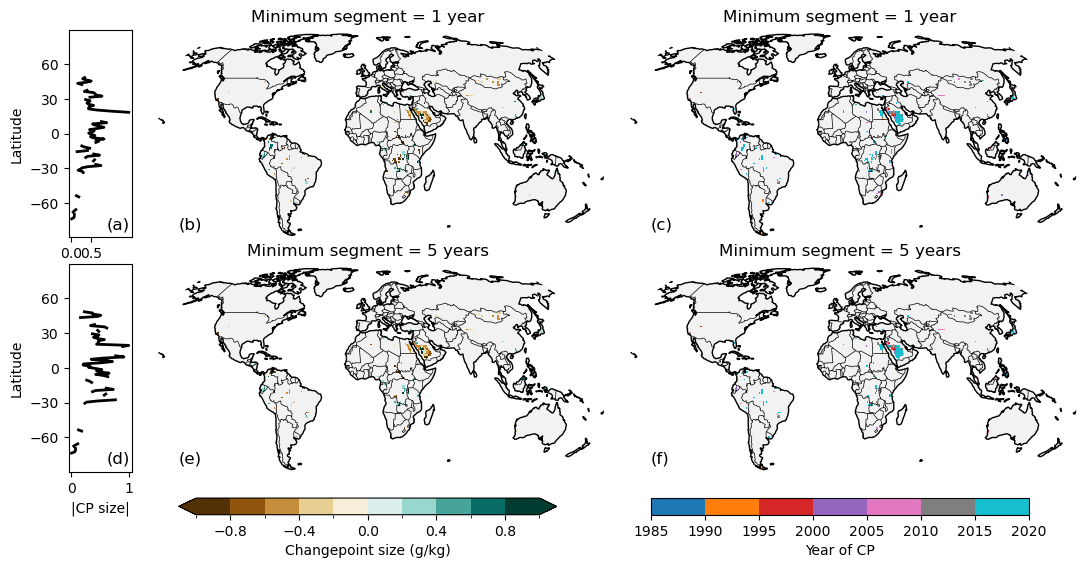

In [81]:
base_str_mag = 'da_delta_at_cp_ERA5_Q2m_1x1_1980-2024_minus_CESM2_QREFHT_1x1_1980-2024_modelmeanar1-trendar1'
base_str_info = 'ds_cp_info_ERA5_Q2m_1x1_1980-2024_minus_CESM2_QREFHT_1x1_1980-2024_modelmeanar1-trendar1'
data_names = ['_max5_minseg12_std', '_max5_minseg60_std']
titles = ['Minimum segment = 1 year', 'Minimum segment = 5 years']
n_data = len(data_names)
nrows = n_data + 1
ncols = 3

proj = ccrs.Robinson(central_longitude=0)
cp_to_plot = 1  # plot first changepoint (0) or second (1)

if cp_to_plot == 0:
    figname = 'figS02'
elif cp_to_plot == 1:
    figname = 'figS03'

fig = plt.figure(figsize=(13, 6.3 / 2 * len(data_names)))

gs = gridspec.GridSpec(
    nrows=nrows,
    ncols=ncols,
    width_ratios=[0.8, 6, 6],
    height_ratios=[1] * n_data + [0.08],
    wspace=0,
    hspace=0.18
)

letter_ct = 0

cbar_info = {
    0: {'im': None, 'label': None, 'extend': None},
    1: {'im': None, 'label': None, 'extend': None},
}

profile_axes = []
first_map_axes = []

for ct, data_name in enumerate(data_names):

    # Plot profile and map
    ax_prof = fig.add_subplot(gs[ct, 0])
    profile_axes.append(ax_prof)
    

    f = '%s/changepoints_1x1/%s%s.nc' % (procdir, base_str_mag, data_name)
        
    with xr.open_dataarray(f) as da_mag:

        smooth_prof = (
            np.abs(da_mag.where(da_lsmask_1x1 > landcut))
            .sel(cp=cp_to_plot)
            .mean('lon')
            .load()
        )

        lat_min = da_mag['lat'].min().values
        lat_max = da_mag['lat'].max().values
        da_mag = da_mag.sel(cp=cp_to_plot).load()

    cp_info_file = '%s/changepoints_1x1/%s%s.nc' % (procdir, base_str_info, data_name)

    with xr.open_dataset(cp_info_file) as ds_cp_info:
        da_time = ds_cp_info['cp_time'].sel(cp=cp_to_plot).dt.year
        has_cp = ds_cp_info['cp_count'] >= 2
        has_cp = has_cp.load()
        da_time = da_time.where(has_cp & (da_time < years[-1])).load()
        
    da_mag = da_mag.where(da_lsmask_1x1 > landcut)
    da_time = da_time.where(da_lsmask_1x1 > landcut)

    smooth_prof.plot(ax=ax_prof, y='lat', color='k', lw=2)

    if ct == n_data - 1: 
        ax_prof.set_xlabel('|CP size|')
    else:
        ax_prof.set_xlabel('')

    if ct == 0:
        ax_prof.set_xticks((0, 0.5))
    else:
        ax_prof.set_xticks((0, 1))

    ax_prof.set_yticks(np.arange(-60, 80, 30))
    ax_prof.set_ylabel('Latitude')
    ax_prof.set_title('')
    ax_prof.set_ylim(lat_min, lat_max)

    ax_prof.text(
        0.6, 0.04, '(%s)' % letters[letter_ct],
        fontsize=fontsize,
        transform=ax_prof.transAxes
    )
    letter_ct += 1

    for map_ct in range(2):

        ax_map = fig.add_subplot(gs[ct, 1 + map_ct], projection=proj)
        ax_map.set_aspect('equal')
        
        if map_ct == 0:
            first_map_axes.append(ax_map)

            # Plot CP magnitude
            cmap = plt.cm.BrBG
            levels = np.arange(-1, 1.1, 0.2)
            label = 'Changepoint size (g/kg)'
            extend = 'both'
            norm = BoundaryNorm(levels, ncolors=256)    
            to_plot = da_mag

            print(
                'min-max range: %0.2f-%0.2f'
                % (to_plot.min(), to_plot.max())
            )

        else:
            # Plot CP year
            cmap = plt.cm.tab10
            ncolors = 10
            levels = np.arange(1985, 2021, 5)
            label = 'Year of CP'
            extend = 'neither'
            norm = BoundaryNorm(levels, ncolors=ncolors)
            to_plot = da_time

        lon = to_plot['lon'].values
        lat = to_plot['lat'].values
        dat = to_plot.values

        dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

        im = ax_map.pcolormesh(
            lon_cyc,
            lat,
            dat_cyc,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            shading='auto'
        )

        if cbar_info[map_ct]['im'] is None:
            cbar_info[map_ct]['im'] = im
            cbar_info[map_ct]['label'] = label
            cbar_info[map_ct]['extend'] = extend

        ax_map.add_feature(cfeature.LAND, color='0.95', zorder=0)
        ax_map.add_feature(cfeature.COASTLINE, zorder=100)
        ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=100)

        ax_map.set_global()
        ax_map.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
        ax_map.axis('off')
        ax_map.set_title(titles[ct])



        ax_map.text(
            0.10, 0.04, '(%s)' % letters[letter_ct],
            fontsize=fontsize,
            transform=ax_map.transAxes
        )
        letter_ct += 1


# Force profile axes to match the final Cartopy map heights
fig.canvas.draw()

for ax_prof, ax_map in zip(profile_axes, first_map_axes):
    pos_map = ax_map.get_position()
    pos_prof = ax_prof.get_position()
    ax_prof.set_position([
        pos_prof.x0,
        pos_map.y0,
        pos_prof.width,
        pos_map.height
    ])


# Empty lower-left cell
ax_empty = fig.add_subplot(gs[-1, 0])
ax_empty.axis('off')


# Colorbars in the bottom GridSpec row
# Colorbars in the bottom GridSpec row, spanning 80% of each map-column axis
for map_ct in range(2):

    cax = fig.add_subplot(gs[-1, 1 + map_ct])

    # shrink colorbar axis to 80% width, centered in its GridSpec cell
    fig.canvas.draw()
    pos = cax.get_position()

    frac = 0.8
    new_width = frac * pos.width
    new_x0 = pos.x0 + 0.5 * (pos.width - new_width)

    cax.set_position([
        new_x0,
        pos.y0,
        new_width,
        pos.height
    ])

    cbar = fig.colorbar(
        cbar_info[map_ct]['im'],
        cax=cax,
        orientation='horizontal',
        extend=cbar_info[map_ct]['extend']
    )

    cbar.set_label(cbar_info[map_ct]['label'])


plt.savefig('%s/%s.png' % (figdir, figname), dpi=200, bbox_inches='tight')

# Figure S4: maps of characteristics

In [ ]:
# Make plot
nrows = 3
ncols = 1
proj = ccrs.Robinson(central_longitude=0)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(8 * ncols, 4 * nrows),
    subplot_kw={'projection': proj}
)

for ct, ax in enumerate(np.atleast_1d(axes).flatten()):

    if ct == 0:
        to_plot = ds_residual_metrics['clim_std'].mean('month')
        cmap = plt.cm.viridis
        label = r'Average $\sigma$ across months (g/kg)'
        levels = np.arange(0, 1.1, 0.1)

    elif ct == 1:
        to_plot = 10 * ds_residual_metrics['trend']
        cmap = plt.cm.BrBG_r
        label = 'Trend (g/kg/decade)'
        levels = np.arange(-0.5, 0.6, 0.1)

    else:
        to_plot = ds_residual_metrics['ar1']
        cmap = plt.cm.Reds
        label = 'AR(1) coefficient ([])'
        levels = np.arange(0, 0.7, 0.1)

    norm = BoundaryNorm(levels, ncolors=256)
    to_plot = to_plot.where(is_land)

    # pcolormesh expects arrays; add cyclic point to avoid a seam at 180°
    lon = to_plot['lon'].values
    lat = to_plot['lat'].values
    dat = to_plot.values
    dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

    im = ax.pcolormesh(
        lon_cyc,
        lat,
        dat_cyc,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.set_aspect('equal')
    ax.add_feature(cfeature.COASTLINE, zorder=100.)
    ax.set_global()
    ax.axis('off')
    ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
    ax.set_title('')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.text(0.02, 0.06, '(%s)' % letters[ct], fontsize=fontsize, transform=ax.transAxes)

    # Colorbar per panel (manual, like your other figure)
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)
    cbar.set_label(label)

plt.savefig('%s/figS04.png' % figdir, dpi=200, bbox_inches='tight')

# Figure S5: hit/miss histogram for 2 CPs

<xarray.DataArray ()> Size: 8B
array(751)
FA per hit: 0.056


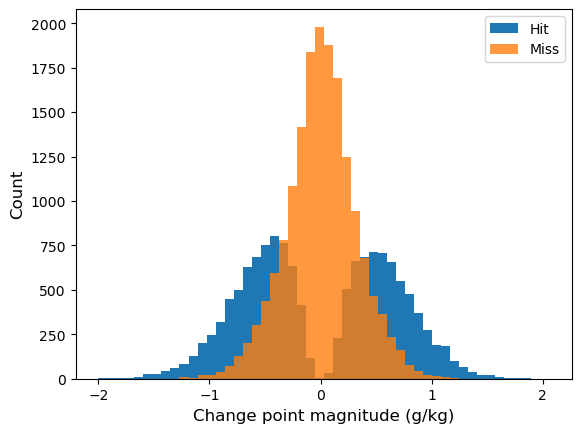

In [26]:
namestr = '_with_skew'
n_cp = 2
synth_cp_std = 0.5
seed = 0

# Contains the trend, AR(1), and seasonally-varying variance for each gridbox
ds_residual_metrics = xr.open_dataset('%s/residual_metrics.nc' % procdir)

# landmask
mask = is_land

# New filename tag
file_tag = '%s_ncp-%i_sigma-%0.1f_seed-%i' % (
    namestr, n_cp, synth_cp_std, seed
)

# Truth
# actual changepoint magnitude
da_cp_synth_mult = xr.open_dataarray(
    '%s/synth_cps_cpmag%s.nc' % (procdir, file_tag)
)

# actual changepoint time index -- cannot be in first and last 5 years
da_cp_time_synth_mult = xr.open_dataarray(
    '%s/synth_cps_time%s.nc' % (procdir, file_tag)
)

# Output from using PELT
# detected changepoint magnitude
da_delta_at_cp_synth_mult = xr.open_dataarray(
    '%s/da_delta_at_cp_synth%s.nc' % (procdir, file_tag)
)

# other info e.g. time of changepoint
ds_cp_info_synth_mult = xr.open_dataset(
    '%s/ds_cp_info_synth%s.nc' % (procdir, file_tag)
)

tol = 12  # CPs count if they are within tol months of what is found

def _ensure_cp_dim(da, new_name):
    if 'cp' in da.dims:
        return da.rename({'cp': new_name})
    else:
        return da.expand_dims({new_name: [0]})


idx_actual = _ensure_cp_dim(da_cp_time_synth_mult, 'cp_actual')
cp_actual = _ensure_cp_dim(da_cp_synth_mult, 'cp_actual')

idx_detected = ds_cp_info_synth_mult['cp_index'].rename({'cp': 'cp_detected'})
delta_detected = da_delta_at_cp_synth_mult.rename({'cp': 'cp_detected'})

# If no CP is found, then envCpt puts out the last index (so cp_count = 1 means no co)
n_detected = ds_cp_info_synth_mult['cp_count'] - 1

if n_cp == 0:
    n_fa = n_detected.where(n_detected > 0).sum()
    print('False alarms: %i' % n_fa)
    
def classify_cp_matches(actual_idx, detected_idx, n_detected, tol=12):
    """
    One-to-one matching between true and detected changepoints.
    Operates on one set of changepoints, and then applied with apply_ufunc

    Returns
    -------
    hit : bool, shape (n_actual,)
        True CP was matched by a detected CP within tol.
    miss : bool, shape (n_actual,)
        True CP was not matched.
    false_alarm : bool, shape (n_detected_slots,)
        Detected CP was not matched to any true CP.
    """
    
    # Index of actual changepoints 
    actual_idx = np.asarray(actual_idx, dtype=float)
    # Index of identified changepoints
    detected_idx = np.asarray(detected_idx, dtype=float)

    # Number of actual changepoints
    n_actual = actual_idx.size
    # Number of changepoints that could be detected (model parameter)
    n_detected_slots = detected_idx.size

    # Hit/miss is defined per real changepoint
    hit = np.zeros(n_actual, dtype=bool)
    miss = np.zeros(n_actual, dtype=bool)
    detected_matched = np.zeros(n_detected_slots, dtype=bool)
    
    # False alarm can happen if additional CPs are identified 
    false_alarm = np.zeros(n_detected_slots, dtype=bool)

    if not np.isfinite(n_detected):
        n_detected = 0

    n_detected = int(n_detected)
    n_detected = max(0, min(n_detected, n_detected_slots))

    valid_actual = np.isfinite(actual_idx)

    valid_detected = np.zeros(n_detected_slots, dtype=bool)
    valid_detected[:n_detected] = np.isfinite(detected_idx[:n_detected])

    candidates = []

    for a in np.where(valid_actual)[0]:
        for d in np.where(valid_detected)[0]:
            dist = np.abs(detected_idx[d] - actual_idx[a])
            if dist <= tol:
                candidates.append((dist, a, d))

    # Greedy nearest-neighbor one-to-one matching
    candidates = sorted(candidates, key=lambda x: x[0])

    for _, a, d in candidates:
        if (not hit[a]) and (not detected_matched[d]):
            hit[a] = True
            detected_matched[d] = True

    
    miss = valid_actual & ~hit
    false_alarm = valid_detected & ~detected_matched

    return hit, miss, false_alarm

hit_actual, miss_actual, false_alarm_detected = xr.apply_ufunc(
    classify_cp_matches,
    idx_actual,
    idx_detected,
    n_detected,
    input_core_dims=[['cp_actual'], ['cp_detected'], []],
    output_core_dims=[['cp_actual'], ['cp_actual'], ['cp_detected']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[bool, bool, bool],
    kwargs={'tol': tol},
    dask_gufunc_kwargs={
        'output_sizes': {
            'cp_actual': idx_actual.sizes['cp_actual'],
            'cp_detected': idx_detected.sizes['cp_detected'],
        }
    },
)

hit_actual = hit_actual.assign_coords(cp_actual=idx_actual['cp_actual'])
miss_actual = miss_actual.assign_coords(cp_actual=idx_actual['cp_actual'])
false_alarm_detected = false_alarm_detected.assign_coords(
    cp_detected=idx_detected['cp_detected']
)

print(np.sum(false_alarm_detected))

fontsize = 12
fig, ax = plt.subplots()
vals_hit = cp_actual.where(hit_actual & mask).values.flatten()
vals_miss = cp_actual.where(miss_actual & mask).values.flatten()


vals_hit = vals_hit[np.isfinite(vals_hit)]
vals_miss = vals_miss[np.isfinite(vals_miss)]

nhit, bins, _ = ax.hist(vals_hit, bins=50, label='Hit')
ax.hist(vals_miss, bins=bins, label='Miss', alpha=0.8)

ax.legend()
ax.set_xlabel('Change point magnitude (g/kg)', fontsize=fontsize)
ax.set_ylabel('Count', fontsize=12)
plt.savefig('R_multiple_CPs.png', dpi=200, bbox_inches='tight')
ax.set_xticks([-2, -1, 0, 1, 2])
fa_rate = false_alarm_detected.sum() / hit_actual.sum()
print('FA per hit: %0.3f' % fa_rate)

plt.savefig('%s/figS05.png' % figdir, dpi=200, bbox_inches='tight')

# Figure S6: Validating changepoint magnitude for hits

In [ ]:
true_mag = da_cp_synth.where(hit).values.flatten()
predicted_mag = da_delta_at_cp_synth.isel(cp=0).values.flatten()

fig, axes = plt.subplots(figsize=(8, 3), ncols=2)
for ct, ax in enumerate(axes):
    if ct == 0:
        ax.plot(true_mag, predicted_mag ,'.')
        ax.plot([-2, 2], [-2,2 ], color='k')
        ax.grid()
        ax.set_xlabel('True changepoint magnitude (g/kg)')
        ax.set_ylabel('Predicted changepoint \nmagnitude (g/kg)')
    else:
        delta = predicted_mag - true_mag
        ax.hist(delta, bins=20, density=True)
        ax.set_xlabel('Predicted minus true (g/kg)')
        ax.set_ylabel('Density')
    ax.text(0.02, 0.93, '(%s)' % letters[ct], fontsize=fontsize, transform=ax.transAxes)

plt.savefig('%s/figS06.png' % figdir, dpi=200, bbox_inches='tight')

print('bias: %0.2f g/kg' % np.nanmean(delta))
print('standard error: %0.2f g/kg' % np.nanstd(delta))

for ct in range(2):
    
    if ct == 0:
        idx = true_mag > 0
        print('positive CPs')
    else:
        idx = true_mag < 0
        print('negative CPs')
   
    print('bias: %0.2f g/kg' % np.nanmean(delta[idx]))
    print('standard error: %0.2f g/kg' % np.nanstd(delta[idx]))


In [ ]:
# compare magnitude of detected changepoints with what we could have seen
f = '%s/da_delta_at_cp_withAR_%s_%04i-%04i.nc' % (procdir, 'ERA5', years[0], years[1])
with xr.open_dataarray(f) as da_mag:
    era5_cp = da_mag.sel(cp=0)

# Figure S7: made above with Fig 2 using second changepoint

# Figure S8, S9: JRA-3Q CPs 1 and 2

min-max range: -1.15-1.06
min-max range: -1.56-1.68


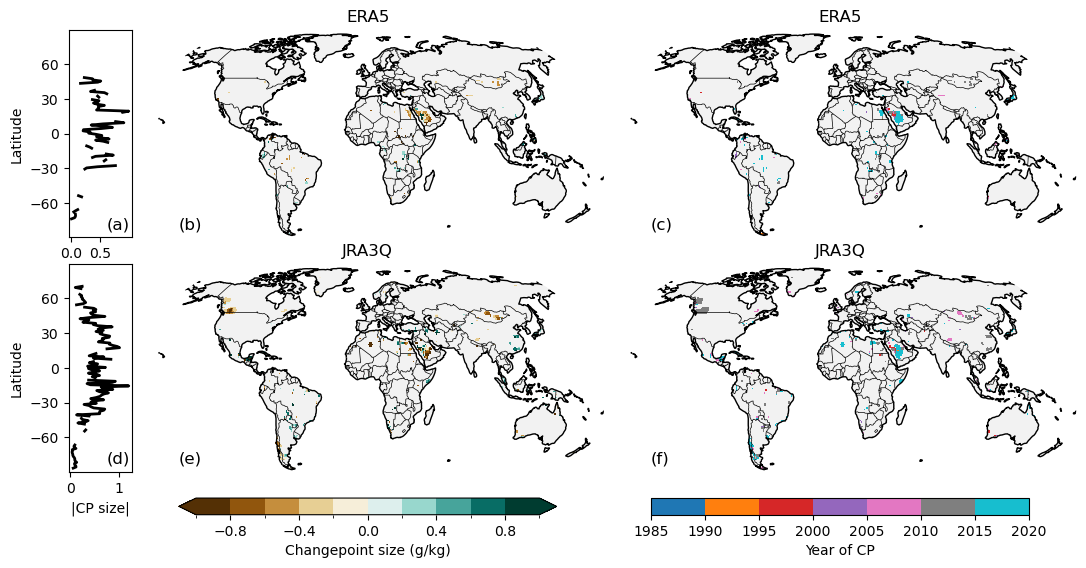

In [18]:
data_names = ['ERA5', 'JRA3Q']

n_data = len(data_names)
nrows = n_data + 1
ncols = 3

proj = ccrs.Robinson(central_longitude=0)
cp_to_plot = 1  # plot first changepoint (0) or second (1)
if cp_to_plot == 0:
    figname = 'figS08'
elif cp_to_plot == 1:
    figname = 'figS09'

fig = plt.figure(figsize=(13, 6.3))

gs = gridspec.GridSpec(
    nrows=nrows,
    ncols=ncols,
    width_ratios=[0.8, 6, 6],
    height_ratios=[1] * n_data + [0.08],
    wspace=0,
    hspace=0.18
)

letter_ct = 0

cbar_info = {
    0: {'im': None, 'label': None, 'extend': None},
    1: {'im': None, 'label': None, 'extend': None},
}

profile_axes = []
first_map_axes = []

for ct, data_name in enumerate(data_names):

    # Plot profile and map
    ax_prof = fig.add_subplot(gs[ct, 0])
    profile_axes.append(ax_prof)
    

    f = '%s/changepoints_1x1/da_delta_at_cp_withAR_%s_Q2m_minus_CESM2_QREFHT.nc' % (procdir, data_name)
        
    with xr.open_dataarray(f) as da_mag:

        smooth_prof = (
            np.abs(da_mag.where(da_lsmask_1x1 > landcut))
            .sel(cp=cp_to_plot)
            .mean('lon')
            .load()
        )

        lat_min = da_mag['lat'].min().values
        lat_max = da_mag['lat'].max().values
        da_mag = da_mag.sel(cp=cp_to_plot).load()

    cp_info_file = '%s/changepoints_1x1/ds_cp_info_%s_Q2m_minus_CESM2_QREFHT.nc' % (procdir, data_name)

    with xr.open_dataset(cp_info_file) as ds_cp_info:
        da_time = ds_cp_info['cp_time'].sel(cp=cp_to_plot).dt.year
        has_cp = ds_cp_info['cp_count'] >= 2
        has_cp = has_cp.load()
        da_time = da_time.where(has_cp & (da_time < years[-1])).load()
        
    da_mag = da_mag.where(da_lsmask_1x1 > landcut)
    da_time = da_time.where(da_lsmask_1x1 > landcut)

    smooth_prof.plot(ax=ax_prof, y='lat', color='k', lw=2)

    if ct == n_data - 1: 
        ax_prof.set_xlabel('|CP size|')
    else:
        ax_prof.set_xlabel('')

    if ct == 0:
        ax_prof.set_xticks((0, 0.5))
    else:
        ax_prof.set_xticks((0, 1))

    ax_prof.set_yticks(np.arange(-60, 80, 30))
    ax_prof.set_ylabel('Latitude')
    ax_prof.set_title('')
    ax_prof.set_ylim(lat_min, lat_max)

    ax_prof.text(
        0.6, 0.04, '(%s)' % letters[letter_ct],
        fontsize=fontsize,
        transform=ax_prof.transAxes
    )
    letter_ct += 1

    for map_ct in range(2):

        ax_map = fig.add_subplot(gs[ct, 1 + map_ct], projection=proj)
        ax_map.set_aspect('equal')
        
        if map_ct == 0:
            first_map_axes.append(ax_map)

            # Plot CP magnitude
            cmap = plt.cm.BrBG
            levels = np.arange(-1, 1.1, 0.2)
            label = 'Changepoint size (g/kg)'
            extend = 'both'
            norm = BoundaryNorm(levels, ncolors=256)    
            to_plot = da_mag

            print(
                'min-max range: %0.2f-%0.2f'
                % (to_plot.min(), to_plot.max())
            )

        else:
            # Plot CP year
            cmap = plt.cm.tab10
            ncolors = 10
            levels = np.arange(1985, 2021, 5)
            label = 'Year of CP'
            extend = 'neither'
            norm = BoundaryNorm(levels, ncolors=ncolors)
            to_plot = da_time

        lon = to_plot['lon'].values
        lat = to_plot['lat'].values
        dat = to_plot.values

        dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

        im = ax_map.pcolormesh(
            lon_cyc,
            lat,
            dat_cyc,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            shading='auto'
        )

        if cbar_info[map_ct]['im'] is None:
            cbar_info[map_ct]['im'] = im
            cbar_info[map_ct]['label'] = label
            cbar_info[map_ct]['extend'] = extend

        ax_map.add_feature(cfeature.LAND, color='0.95', zorder=0)
        ax_map.add_feature(cfeature.COASTLINE, zorder=100)
        ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=100)

        ax_map.set_global()
        ax_map.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
        ax_map.axis('off')
        ax_map.set_title(data_name)



        ax_map.text(
            0.10, 0.04, '(%s)' % letters[letter_ct],
            fontsize=fontsize,
            transform=ax_map.transAxes
        )
        letter_ct += 1


# Force profile axes to match the final Cartopy map heights
fig.canvas.draw()

for ax_prof, ax_map in zip(profile_axes, first_map_axes):
    pos_map = ax_map.get_position()
    pos_prof = ax_prof.get_position()
    ax_prof.set_position([
        pos_prof.x0,
        pos_map.y0,
        pos_prof.width,
        pos_map.height
    ])


# Empty lower-left cell
ax_empty = fig.add_subplot(gs[-1, 0])
ax_empty.axis('off')


# Colorbars in the bottom GridSpec row
# Colorbars in the bottom GridSpec row, spanning 80% of each map-column axis
for map_ct in range(2):

    cax = fig.add_subplot(gs[-1, 1 + map_ct])

    # shrink colorbar axis to 80% width, centered in its GridSpec cell
    fig.canvas.draw()
    pos = cax.get_position()

    frac = 0.8
    new_width = frac * pos.width
    new_x0 = pos.x0 + 0.5 * (pos.width - new_width)

    cax.set_position([
        new_x0,
        pos.y0,
        new_width,
        pos.height
    ])

    cbar = fig.colorbar(
        cbar_info[map_ct]['im'],
        cax=cax,
        orientation='horizontal',
        extend=cbar_info[map_ct]['extend']
    )

    cbar.set_label(cbar_info[map_ct]['label'])


plt.savefig('%s/%s.png' % (figdir, figname), dpi=200, bbox_inches='tight')

# Figure S10: Matching magnitude/time between ERA5 and HadISDH

In [20]:
fname = '%s/changepoints_1x1/da_delta_at_cp_withAR_ERA5_Q2m_minus_CESM2_QREFHT.nc' % procdir
era5_cp_mag = xr.open_dataarray(fname)

fname = '%s/da_delta_at_cp_withAR_%s_%04i-%04i.nc' % (procdir, 'HadISDH', years[0], years[1])
hadisdh_cp_mag = xr.open_dataarray(fname)

fname = '%s/changepoints_1x1/ds_cp_info_ERA5_Q2m_minus_CESM2_QREFHT.nc' % procdir
era5_cp_info = xr.open_dataset(fname)

fname = '%s/ds_cp_info_%s_%i-%i.nc' % (procdir, 'HadISDH', years[0], years[1])
hadisdh_cp_info = xr.open_dataset(fname)

era5_cp_mag = era5_cp_mag.where(is_land)
era5_cp_info = era5_cp_info.where(is_land)

In [21]:
cp_index = 0
year_tol = 2  # use 1 for ±1 year; 5 for ±5 years

# HadISDH selected CP magnitude and time
had = hadisdh_cp_mag.sel(cp=cp_index)
had_time = hadisdh_cp_info['cp_time'].sel(cp=cp_index)

# ERA5 all CP magnitudes and times
era = era5_cp_mag
era_time = era5_cp_info['cp_time']

# Make sure ERA5 time has the same dimension order as ERA5 magnitude
era_time = era_time.transpose(*era.dims)

# Check match in sign and year
class_map = xr.full_like(had, np.nan, dtype=float)
class_map_time = xr.full_like(had, np.nan, dtype=float)

half_width = 2.5
year_tol = 1  # HadISDH year ± 1 year

for hlat in had.lat.values:
    for hlon in had.lon.values:

        had_val = had.sel(lat=hlat, lon=hlon).values
        had_t = had_time.sel(lat=hlat, lon=hlon).values

        # Only classify where HadISDH has a changepoint
        if not np.isfinite(had_val):
            continue

        had_sign = np.sign(had_val)

        # ERA5 cells inside this HadISDH 5x5 box
        lat_mask = (era.lat >= hlat - half_width) & (era.lat < hlat + half_width)
        lon_mask = (era.lon >= hlon - half_width) & (era.lon < hlon + half_width)

        era_box = era.where(lat_mask & lon_mask, drop=True)
        era_time_box = era_time.where(lat_mask & lon_mask, drop=True)

        # Use ERA5 CP magnitude to define whether ERA5 has a changepoint.
        # This keeps the zero category identical for both maps.
        valid_era_cp = np.isfinite(era_box)

        era_vals = era_box.where(valid_era_cp).values.ravel()
        era_vals = era_vals[np.isfinite(era_vals)]

        era_times = era_time_box.where(valid_era_cp).values.ravel()
        era_times = era_times[~np.isnat(era_times)]

        # --------------------------------------------------
        # Category 0: no ERA5 changepoint in the box
        # --------------------------------------------------

        if len(era_vals) == 0:
            class_map.loc[dict(lat=hlat, lon=hlon)] = 0
            class_map_time.loc[dict(lat=hlat, lon=hlon)] = 0
            continue

        # --------------------------------------------------
        # Sign agreement class map
        # --------------------------------------------------

        if np.any(np.sign(era_vals) == had_sign):
            class_map.loc[dict(lat=hlat, lon=hlon)] = 2
        else:
            class_map.loc[dict(lat=hlat, lon=hlon)] = 1

        # --------------------------------------------------
        # Time agreement class map
        # --------------------------------------------------

        if np.isnat(had_t):
            continue

        had_year = had_t.astype('datetime64[Y]').astype(int) + 1970
        era_years = era_times.astype('datetime64[Y]').astype(int) + 1970

        if np.any(np.abs(era_years - had_year) <= year_tol):
            class_map_time.loc[dict(lat=hlat, lon=hlon)] = 2
        else:
            class_map_time.loc[dict(lat=hlat, lon=hlon)] = 1

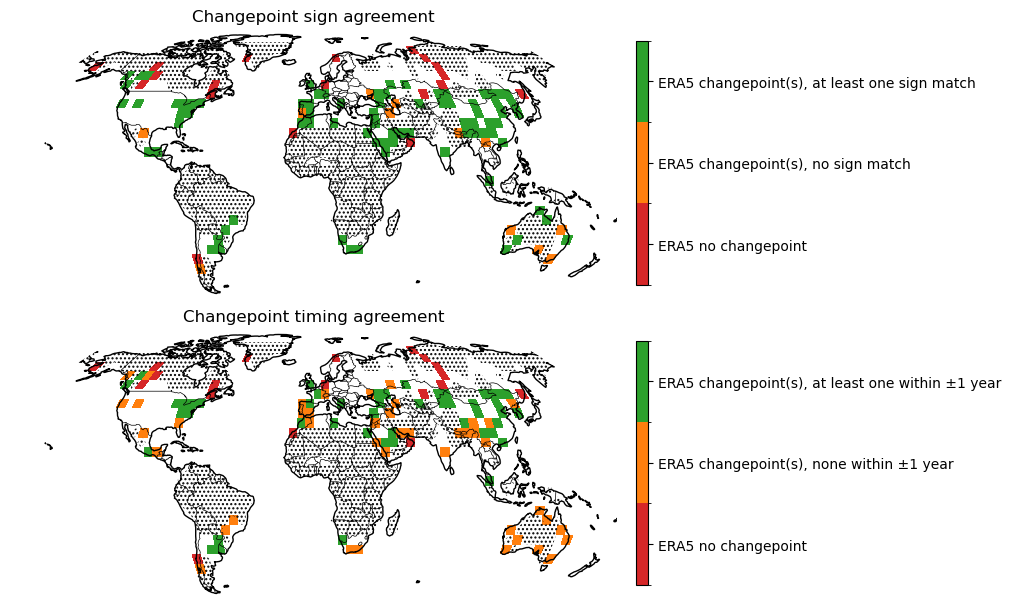

In [22]:
proj = ccrs.Robinson(central_longitude=0)

fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 6),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

cmap = ListedColormap([
    'tab:red',     # 0: no ERA5 changepoint
    'tab:orange',  # 1: ERA5 changepoint(s), no match
    'tab:green',   # 2: ERA5 changepoint(s), match
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Prepare HadISDH hatch overlay once
had_lon = had_mask['lon'].values
had_lat = had_mask['lat'].values
had_dat = had_mask.values
had_cyc, had_lon_cyc = add_cyclic_point(had_dat, coord=had_lon)

# -------- Top panel: sign match --------
ax = axs[0]

im1 = class_map.plot.pcolormesh(
    ax=ax,
    x='lon',
    y='lat',
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.contourf(
    had_lon_cyc,
    had_lat,
    had_cyc,
    levels=[-0.5, 0.5, 1.5],
    hatches=[None, '....'],
    colors='none',
    transform=ccrs.PlateCarree(),
    zorder=101
)

ax.add_feature(cfeature.COASTLINE, zorder=100)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=100)
ax.set_global()
ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
ax.axis('off')
ax.set_title('Changepoint sign agreement')

cbar1 = fig.colorbar(im1, ax=ax, ticks=[0, 1, 2], shrink=0.9, pad=0.03)
cbar1.ax.set_yticklabels([
    'ERA5 no changepoint',
    'ERA5 changepoint(s), no sign match',
    'ERA5 changepoint(s), at least one sign match',
])

# -------- Bottom panel: time match --------
ax = axs[1]

im2 = class_map_time.plot.pcolormesh(
    ax=ax,
    x='lon',
    y='lat',
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.contourf(
    had_lon_cyc,
    had_lat,
    had_cyc,
    levels=[-0.5, 0.5, 1.5],
    hatches=[None, '....'],
    colors='none',
    transform=ccrs.PlateCarree(),
    zorder=101
)

ax.set_aspect('equal')
ax.add_feature(cfeature.COASTLINE, zorder=100)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=100)
ax.set_global()
ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
ax.axis('off')
ax.set_title('Changepoint timing agreement')

cbar2 = fig.colorbar(im2, ax=ax, ticks=[0, 1, 2], shrink=0.9, pad=0.03)
cbar2.ax.set_yticklabels([
    'ERA5 no changepoint',
    'ERA5 changepoint(s), none within ±%i year' % year_tol,
    'ERA5 changepoint(s), at least one within ±%i year' % year_tol,
])

plt.savefig('%s/figS10.png' % figdir, dpi=200, bbox_inches='tight')
plt.show()

# Figure S11: time series of specific regions

In [23]:
# Load ERA5 and ERA5 corrected
f_era5 = '%s/ERA5_q_1x1_1980-2025.nc' % procdir
f_era5_corrected = '%s/corrected_ERA5_q_withAR_1980-2025.nc' % procdir

da_era5_orig = xr.open_dataarray(f_era5)
da_era5_corrected = xr.open_dataarray(f_era5_corrected)

In [24]:
# Fix possible broken PROJ path in this conda env
import os
import sys
from pathlib import Path

possible_proj_dirs = [
    Path(sys.prefix) / 'share' / 'proj',
]

for p in possible_proj_dirs:
    if p.exists():
        os.environ['PROJ_LIB'] = str(p)
        os.environ['PROJ_DATA'] = str(p)
        break

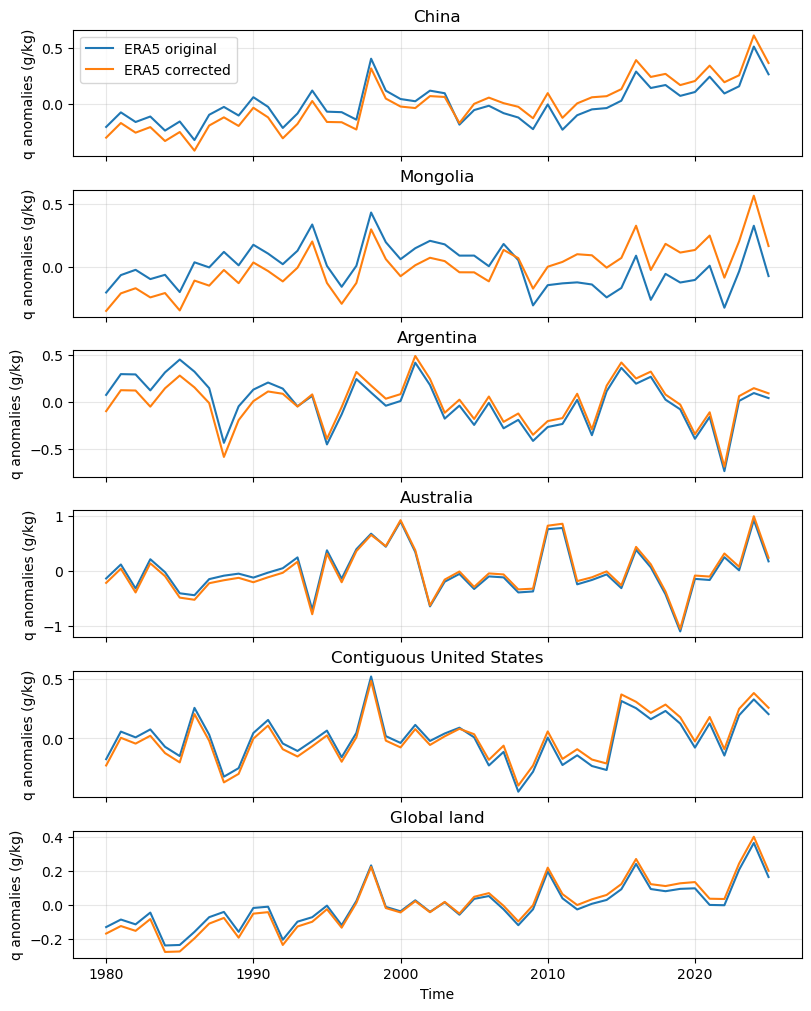

In [32]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import regionmask

datasets = {
    'ERA5 original': da_era5_orig,
    'ERA5 corrected': da_era5_corrected,
}

# Actual polygon borders
countries = regionmask.defined_regions.natural_earth_v5_0_0.countries_10
states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_10

country_nums = dict(zip(countries.names, countries.numbers))
state_nums = dict(zip(states.names, states.numbers))

conus_states = [
    'Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado',
    'Connecticut', 'Delaware', 'District of Columbia', 'Florida',
    'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas',
    'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts',
    'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana',
    'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico',
    'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma',
    'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
    'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
    'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming',
]

regions = {
    'China': {
        'type': 'country',
        'name': 'China',
    },
    'Mongolia': {
        'type': 'country',
        'name': 'Mongolia',
    },
    'Argentina': {
        'type': 'country',
        'name': 'Argentina',
    },
    'Australia': {
        'type': 'country',
        'name': 'Australia',
    },
    'Contiguous United States': {
        'type': 'states',
        'names': conus_states,
    },
      'Global land': {
        'type': 'n/a',
        'names': 'Global land',
    },
      
}

def make_region_mask(da, region):
    """
    Boolean lat/lon mask from actual Natural Earth polygons.
    """

    lon = da['lon']
    lat = da['lat']

    if region['type'] == 'country':
        mask = countries.mask(
            lon,
            lat,
            wrap_lon=True,
            flag='names',
        )

        return mask == country_nums[region['name']]

    if region['type'] == 'states':
        mask = states.mask(
            lon,
            lat,
            wrap_lon=True,
            flag='names',
        )

        nums = [state_nums[s] for s in region['names']]
        return mask.isin(nums)

    raise ValueError(f'Unknown region type: {region["type"]}')



def area_mean_region(da, region):
    """
    Area-weighted regional mean using polygon mask.

    Uses zero weights outside the region because xarray.weighted()
    does not allow NaNs in the weights.
    """

    region_mask = make_region_mask(da, region)

    # Make sure this is strictly boolean
    region_mask = region_mask.fillna(False).astype(bool)

    # 1D latitude weights
    lat_weights = xr.DataArray(
        np.cos(np.deg2rad(da['lat'])),
        dims=('lat',),
        coords={'lat': da['lat']},
    )

    # Broadcast to lat/lon and set weights outside region to zero
    weights = lat_weights.broadcast_like(region_mask)
    weights = weights.where(region_mask, 0).fillna(0)

    ts = (
        da
        .where(region_mask)
        .weighted(weights)
        .mean(('lat', 'lon'), skipna=True)
    )

    return ts

fig, axes = plt.subplots(
    nrows=len(regions),
    ncols=1,
    figsize=(8, 10),
    sharex=True,
    constrained_layout=True,
)

for ax, (region_name, region) in zip(axes, regions.items()):

    for label, da in datasets.items():
        if region_name == 'Global land':
            weights = np.cos(np.deg2rad(da.lat))
            ts = (
                da
                .where(is_land)
                .weighted(weights)
                .mean(('lat', 'lon'), skipna=True)
            ) 
        else:
            ts = area_mean_region(da, region)
        ts = ts.groupby('time.month') - ts.groupby('time.month').mean()
        ts = ts.groupby('time.year').mean()
        ts.plot(ax=ax, label=label)

    ax.set_title(region_name)
    ax.set_xlabel('')
    ax.set_ylabel(da.name if da.name is not None else 'q anomalies (g/kg)')
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='best')
axes[-1].set_xlabel('Time')

plt.savefig('%s/figS11.png' % figdir, dpi=200, bbox_inches='tight')

In [31]:
region_name

'Global land'

# Figure S14: map of arid / semiarid regions

In [ ]:
nrows = 1
ncols = 1
proj = ccrs.Robinson(central_longitude=0)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(8 * ncols, 4 * nrows),
    subplot_kw={'projection': proj}
)

for ct, ax in enumerate(np.atleast_1d(axes).flatten()):

    if ct == 0:
        to_plot = is_arid_semi
        cmap = plt.cm.Grays
        label = r'Is arid/semiarid'
        levels = np.arange(0, 1.1, 0.1)

    norm = BoundaryNorm(levels, ncolors=256)
    to_plot = to_plot.sel(lat=slice(-60, 80))
    # pcolormesh expects arrays; add cyclic point to avoid a seam at 180°
    lon = to_plot['lon'].values
    lat = to_plot['lat'].values
    dat = to_plot.values
    dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

    im = ax.pcolormesh(
        lon_cyc,
        lat,
        dat_cyc,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.set_aspect('equal')
    ax.add_feature(cfeature.COASTLINE, zorder=100.)
    ax.set_global()
    ax.axis('off')
    ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
    ax.set_title('')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1)


plt.savefig('%s/figS14.png' % figdir, dpi=200, bbox_inches='tight')

# Figure S16: residuals with 20CR

In [ ]:
# Load ERA5
da_target = xr.open_dataarray('%s/ERA5_q_1x1.nc' % procdir).load()

# Load 20CR
da_reference = xr.open_dataarray('/home/data/20CR/monthly/shum/shum.2m.mon.mean_ERA5grid1x1.nc')

da_delta = (da_target - da_reference).load()

# Remove differences in mean seasonal cycle
da_delta = da_delta.groupby('time.month') - da_delta.groupby('time.month').mean()

# For each gridbox, calculate trend, variance, AR(1)
trend, _ = xutils.xr_linregress_pval(da_delta, time_dim='time')

# remove trend to get variance
da_detrended = xutils.detrend_xarray(da_delta, dim='time')

std_by_month = da_detrended.groupby('time.month').std()

# get autocorrelation -- shift by 1
ar1 = xr.corr(da_detrended.shift(time=1), da_detrended, dim='time')

# Save these metrics
ds_metrics = xr.merge((trend.rename('trend per year'),
                       std_by_month.rename('sigma'),
                       ar1.rename('AR1 coeff')))


In [ ]:
nrows = 3
ncols = 1
proj = ccrs.Robinson(central_longitude=0)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(8 * ncols, 4 * nrows),
    subplot_kw={'projection': proj}
)

for ct, ax in enumerate(np.atleast_1d(axes).flatten()):

    if ct == 0:
        to_plot = std_by_month.mean('month')
        cmap = plt.cm.viridis
        label = r'Average $\sigma$ across months (g/kg)'
        levels = np.arange(0, 1.1, 0.1)

    elif ct == 1:
        to_plot = 10 * trend
        cmap = plt.cm.BrBG_r
        label = 'Trend (g/kg/decade)'
        levels = np.arange(-0.5, 0.6, 0.1)

    else:
        to_plot = ar1
        cmap = plt.cm.Reds
        label = 'AR(1) coefficient ([])'
        levels = np.arange(0, 0.7, 0.1)

    norm = BoundaryNorm(levels, ncolors=256)
    to_plot = to_plot.sel(lat=slice(-60, 80))
    # pcolormesh expects arrays; add cyclic point to avoid a seam at 180°
    lon = to_plot['lon'].values
    lat = to_plot['lat'].values
    dat = to_plot.values
    dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

    im = ax.pcolormesh(
        lon_cyc,
        lat,
        dat_cyc,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.set_aspect('equal')
    ax.add_feature(cfeature.COASTLINE, zorder=100.)
    ax.set_global()
    ax.axis('off')
    ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
    ax.set_title('')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1)

    ax.text(0.02, 0.06, '(%s)' % letters[ct], fontsize=fontsize, transform=ax.transAxes)

    # Colorbar per panel (manual, like your other figure)
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)
    cbar.set_label(label)

plt.savefig('%s/figS16.png' % figdir, dpi=200, bbox_inches='tight')